<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : Testing spectrum estimation</h1>
    <p style="margin: 10;"></p>
</div>



Here is compared 3 method:

* Orginal version from Widetrax
* New version (Micael code) with modification: change in longitudes and load data using s3fs
* Mix both code: file list from new version implemented in the original

## 📦**Imports** 

In [33]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
#from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
#import tempfile
from shapely.geometry import shape, box
from shapely import geometry
import geopandas as gpd

CPU times: user 39 μs, sys: 5 μs, total: 44 μs
Wall time: 45.8 μs


## 🧮 **Required variables**

In [34]:

season="JFM"
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"





## 🔍 **Check the S3 Endpoint**  

In [35]:
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"
fs = s3fs.S3FileSystem(anon=True,endpoint_url=endpoint_url)
# List contents of the bucket
bucket_name = 's3://project-moi-swot-omip/GLO36V1'
contents = fs.ls(bucket_name)
print("Bucket contents:")
for item in contents:
    print(item)

Bucket contents:
project-moi-swot-omip/GLO36V1/cycle_.keep
project-moi-swot-omip/GLO36V1/cycle_008
project-moi-swot-omip/GLO36V1/cycle_009
project-moi-swot-omip/GLO36V1/cycle_010
project-moi-swot-omip/GLO36V1/cycle_011
project-moi-swot-omip/GLO36V1/cycle_012
project-moi-swot-omip/GLO36V1/cycle_013
project-moi-swot-omip/GLO36V1/cycle_014
project-moi-swot-omip/GLO36V1/cycle_015
project-moi-swot-omip/GLO36V1/cycle_016
project-moi-swot-omip/GLO36V1/cycle_017
project-moi-swot-omip/GLO36V1/cycle_018
project-moi-swot-omip/GLO36V1/cycle_019
project-moi-swot-omip/GLO36V1/cycle_020
project-moi-swot-omip/GLO36V1/cycle_021
project-moi-swot-omip/GLO36V1/cycle_022
project-moi-swot-omip/GLO36V1/cycle_023
project-moi-swot-omip/GLO36V1/cycle_024
project-moi-swot-omip/GLO36V1/cycle_025
project-moi-swot-omip/GLO36V1/cycle_026


## 🔄 **Identify the cycle numbers within the specified time range** 

In [36]:
# NO CHANGES HERE
import DataPreprocessing as dp0

if season=="JFM":    
    start_date = "01012024" # "DDMMYYYY"
    end_date ="31032024"
elif season=="JAS":
    start_date = "01072024" # "DDMMYYYY"
    end_date ="30092024"

if season =="JFM":
    file_path = "https://minio.lab.dive.edito.eu/project-meom-ige/cycles_periods.csv" # works only for winter period
elif season =="JAS":
    file_path = "time_ranges.csv"  # for summer

matching_cycles = dp0.get_matching_cycles(file_path, start_date, end_date)

def formater_numeros_concis(liste_numeros):
  return [str(numero).zfill(3) for numero in liste_numeros]
    
matching_cycles = formater_numeros_concis(matching_cycles)
matching_cycles

['008', '009', '010', '011', '012', '013']

In [37]:
#Define reegion (just one box)

from shapely.geometry import shape, box

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

feature=data["features"][0]
poly = shape(feature["geometry"])

#lon_min, lat_min, lon_max, lat_max. 
# Format longitude 0-360
area = list(poly.bounds)
area[0]=(area[0] + 360) % 360
area[2]=(area[2] + 360) % 360
area = tuple(area)
print(area)


(180.0, -70.0, 190.0, -60.0)


In [38]:
# DEFINED FUNCTION FOR NEW CODE (MICAEL CODE)
def get_half_orbits_intersect(bbox):
    """Get half orbits that intersect a bounding box.
    Parameters
    ----------
    bbox:
        the bounding box

    Returns
    -------
     gpd.GeoDataFrame:
        A Geopandas dataframe containing intersecting half orbits numbers and geometries
    """
    swath_geometries = gpd.read_file(GEOMETRIES_FILE)

    bbox_polygon = geometry.box(*bbox)

    def _filter_intersect(row, polygon):
        half_orbit_polygon = row.geometry
        return polygon.intersects(half_orbit_polygon)

    select = swath_geometries.apply(_filter_intersect, polygon=bbox_polygon, axis=1)
    return swath_geometries[select]


def swath_search(lsw, lNE, latsw, latNE, GEOMETRIES_FILE):
    
    lon_range = lsw, lNE
    lat_range = latsw, latNE
    bbox = [lon_range[0], lat_range[0], lon_range[1], lat_range[1]]
    plot_extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]   
    swath_geoms = get_half_orbits_intersect(bbox)
    half_orbits = list(swath_geoms['pass_number'])
    
    return np.transpose(half_orbits)

    
import s3fs
from datetime import datetime

import s3fs
from datetime import datetime
import re

def find_listdata(matching_cycles, bucket, pass_numbers, start_date, end_date):
    """
    Find .nc files in S3 matching cycles, pass numbers, and months.

    Parameters:
        matching_cycles (list[int]): List of cycle numbers to search.
        prefix (str): S3 folder prefix (e.g., 'swotce').
        bucket (str): S3 bucket name.
        pass_numbers (list[int]): List of allowed pass numbers.
        start_date (str): Start date in format 'ddmmyyyy'.
        end_date (str): End date in format 'ddmmyyyy'.

    Returns:
        list_files (list[str]): List of S3 keys that match the filters.
    """
    # Convert start/end dates to month integers
    m1 = datetime.strptime(start_date, "%d%m%Y").month
    m2 = datetime.strptime(end_date, "%d%m%Y").month

    # Initialize S3 filesystem USING S3FS
    fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)  # assumes AWS credentials are set in environment or ~/.aws/credentials
    list_files = []

    for cycle_number in matching_cycles:
        # Construct the S3 folder path
        s3_folder = f"{bucket}/cycle_{cycle_number}/"
        
        # Recursively find all .nc files
        all_files = fs.glob(s3_folder + "**/*.nc")  # ** for recursive search

        for filename in all_files:
            # Extract pass number safely (adjust indices if needed)
            # WARNING HEREEE: index not always safe. Look for a safest option
            parts = filename.split("_")
            idx = parts.index('SSH') # HOPING THAT ALL THE FILES HAVE THE FORMAT *_SSH_cycle_passnumber_startdate_enddate*nc
            passnumber=int(parts[idx+2])
            #passnumber = int(filename[-45:-42])  # the swot path pass number 
            month=datetime.strptime(parts[idx+4][:8], "%Y%m%d").month
            #month = datetime.strptime(filename[-41:-33], "%Y%m%d").month  # the month corresponding to the swath
            if (month in range(m1, m2+1)) & (passnumber in pass_numbers): 
                print(filename)
                list_files.append(filename)

  
    print(f"{len(list_files)} files found")
    return list_files



In [9]:

# IGNORE THIS: SOME TEST OF INDEX FILENNALE
#fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)  # assumes AWS credentials are set in environment or ~/.aws/credentials
#3_folder = f"{bucket_name}/cycle_008/"
        
# Recursively find all .nc files
#all_files = fs.glob(s3_folder + "**/*.nc")  # ** for recursive search

#for filename in all_files:
#    parts = filename.split("_")
#   idx = parts.index('SSH')
#    passn=parts[idx+2]
#    month=parts[idx+4][:8]
#    print(parts)
#    print(passn)
#    print(month)
#    with fs.open(filename, mode='rb') as fileObj:
#        ds = xr.open_dataset(fileObj, engine="h5netcdf")
#        lon=ds['longitude'].values
#       #print(lon)
#       ds.close()
    #print(filename[-41:-33])
    #print(filename[-50:-42])

['project-moi-swot-omip/GLO36V1/cycle', '008/SWOT', 'GRID', 'L3', 'LR', 'SSH', '008', '497', '20240101T000706', '20240101T005832', 'v1.0.2.nc']
497
20240101
['project-moi-swot-omip/GLO36V1/cycle', '008/SWOT', 'GRID', 'L3', 'LR', 'SSH', '008', '498', '20240101T005833', '20240101T014959', 'v1.0.2.nc']
498
20240101
['project-moi-swot-omip/GLO36V1/cycle', '008/SWOT', 'GRID', 'L3', 'LR', 'SSH', '008', '499', '20240101T015000', '20240101T024126', 'v1.0.2.nc']
499
20240101
['project-moi-swot-omip/GLO36V1/cycle', '008/SWOT', 'GRID', 'L3', 'LR', 'SSH', '008', '500', '20240101T024126', '20240101T033253', 'v1.0.2.nc']
500
20240101
['project-moi-swot-omip/GLO36V1/cycle', '008/SWOT', 'GRID', 'L3', 'LR', 'SSH', '008', '501', '20240101T033253', '20240101T042420', 'v1.0.2.nc']
501
20240101
['project-moi-swot-omip/GLO36V1/cycle', '008/SWOT', 'GRID', 'L3', 'LR', 'SSH', '008', '502', '20240101T042420', '20240101T051546', 'v1.0.2.nc']
502
20240101
['project-moi-swot-omip/GLO36V1/cycle', '008/SWOT', 'GRID'

KeyboardInterrupt: 

In [39]:
# FIND LIST FILES
from shapely import geometry
prefix='GLO36V1'


lon_min, lat_min, lon_max, lat_max = area

phase = 'science'
GEOMETRIES_FILE = f'KaRIn_2kms_{phase}_geometries.geojson'
pass_numbers = swath_search(lon_min, lon_max, lat_min, lat_max, GEOMETRIES_FILE)

list_files=find_listdata(matching_cycles, bucket_name, pass_numbers, start_date, end_date)




project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_504_20240101T060713_20240101T065840_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_513_20240101T135015_20240101T144141_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_530_20240102T042451_20240102T051617_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_532_20240102T060744_20240102T065911_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_541_20240102T135046_20240102T144212_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_558_20240103T042522_20240103T051648_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_569_20240103T135117_20240103T144243_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_002_20240104T042553_20240104T051719_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_013_20240104T135148_20240104T144314_v1.0.2.nc
project-mo

# Testing methods

## OLD METHOD: FROM WIDETRAX

In [40]:
%%time
# OLD METHOD: FROM WIDETRAX
# usig the code locally load
datasets_dict_ori = dp0.read_swot_ncfiles_S3subfolders(
    s3_folder,
    matching_cycles,
    endpoint_url,
    area)

project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_504_20240101T060713_20240101T065840_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_513_20240101T135015_20240101T144141_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_530_20240102T042451_20240102T051617_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_532_20240102T060744_20240102T065911_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_541_20240102T135046_20240102T144212_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_558_20240103T042522_20240103T051648_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_569_20240103T135117_20240103T144243_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_002_20240104T042553_20240104T051719_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/

## SECOND METHOD: NEW VERSION (Micael code)

In [41]:
%%time
# METHOD 2: ADAPTED VERSION OF MICAEL CODE (change from boto3 to s3fs)

import s3fs
import xarray as xr

fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)

current_key = 0
datasets_dict = {}

for filename in list_files:
    try:
        f = fs.open(filename, mode="rb")   # keep file open
        ds = xr.open_dataset(f, engine="h5netcdf")

        if 'latitude' in ds and 'longitude' in ds:            
            # Handle longitude wrapping
            if lon_min < lon_max:
                lon_selection = (ds['longitude'] >= lon_min) & (ds['longitude'] <= lon_max)
            else:
                lon_selection = ((ds['longitude'] >= lon_min) & (ds['longitude'] <= 360)) | (ds['longitude'] <= lon_max)
                    
            lat_selection = (ds['latitude'] >= lat_min) & (ds['latitude'] <= lat_max)
            # Combine the selection masks
            selection = lat_selection & lon_selection
            
            # Check if selection is valid
            if selection.any():
                # print(f"{filename[61:68]} included.")
                print(f"{filename} included.")
                ds = ds.where(selection, drop=True)
                # Add the dataset to the dictionary if it passed all filters
                datasets_dict[current_key] = ds
                current_key +=1
            else :
                ds.close()
                continue
    except Exception as e:
        print(f"Skipping {filename}: {e}")
        try:
            ds.close()
            f.close()
        except Exception:
            pass
        continue

print(current_key, "datasets are listed")



project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_504_20240101T060713_20240101T065840_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_513_20240101T135015_20240101T144141_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_530_20240102T042451_20240102T051617_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_532_20240102T060744_20240102T065911_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_541_20240102T135046_20240102T144212_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_558_20240103T042522_20240103T051648_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_569_20240103T135117_20240103T144243_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_002_20240104T042553_20240104T051719_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/

## THIRD METHOD: USING THE LIST FILES APPLIED IN PREVIOUS CODE (AMINE CODE)


In [43]:
# =============================================================================
# read_swot_ncfiles_S3folder : code modified from widetrax
# =============================================================================

#From widetrax
def read_swot_ncfiles_S3folder(s3_folder, endpoint_url, area, file_list,engine="h5netcdf"):
    """
    Load NetCDF files from S3 and filter them based on the region of interest.
    
    Parameters
    -----------
    s3_folder : str
        Path to the S3 folder containing NetCDF files.
    endpoint_url : str
        URL of the S3 endpoint.
    area : list
        List with the boundaries of the region of interest [lon_min, lat_min, lon_max, lat_max].
    engine : str, optional
        Engine for reading NetCDF files, default is "h5netcdf".
        
    Returns
    --------
    datasets_dict : Dict
        A dictionary of xarray datasets.
    """
    lon_min, lat_min, lon_max, lat_max = area
    
    # Initialize S3 filesystem
    fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)
    
    # List NetCDF files in the folder
    #file_list = [file for file in fs.ls(s3_folder) if file.endswith('.nc')]
    
    # Initialize the output dictionary
    datasets_dict = {}
    current_key = 0
    
    for file in file_list:
        try:
            # Open the NetCDF file
            with fs.open(file, mode='rb') as fileObj:
                ds = xr.open_dataset(fileObj, engine=engine)
                
                #drop some variables
                ds = ds.drop_vars(["i_num_line", "i_num_pixel"], errors="ignore")
                    
                # Check geographical filtering
                if 'latitude' in ds and 'longitude' in ds:

                    # Handle longitude wrapping
                    if lon_min < lon_max:
                        lon_selection = (ds['longitude'] >= lon_min) & (ds['longitude'] <= lon_max)
                    else:
                        lon_selection = ((ds['longitude'] >= lon_min) & (ds['longitude'] <= 360)) | (ds['longitude'] <= lon_max)
                    
                    lat_selection = (ds['latitude'] >= lat_min) & (ds['latitude'] <= lat_max)
                    
                    # Combine the selection masks
                    selection = lat_selection & lon_selection
                    
                    # Check if selection is valid
                    if selection.any():
                        print(f"{file[61:68]} included.")
                    else :    
                        ds.close()
                        continue
                    
                    # Drop data outside the region
                    ds = ds.where(selection, drop=True)
                    
                    # Check if the filtered dataset has valid data
                    if ds['latitude'].size == 0 or ds['longitude'].size == 0:
                        print(f"File {file} excluded: empty dataset after region filtering.")
                        ds.close()
                        continue
                    
                # Add the dataset to the dictionary if it passed all filters
                datasets_dict[current_key] = ds
                current_key += 1
                
        except Exception as e:
            print(f"Error processing file {file[61:68]}: {e}")
            continue
    
    return datasets_dict




In [44]:
%%time
# FI
datasets_dict0 = read_swot_ncfiles_S3folder(s3_folder, endpoint_url, area, list_files,engine="h5netcdf")

08_504_ included.
08_513_ included.
08_530_ included.
08_532_ included.
08_541_ included.
08_558_ included.
08_569_ included.
09_002_ included.
09_013_ included.
09_030_ included.
09_041_ included.
09_058_ included.
09_069_ included.
09_086_ included.
09_095_ included.
09_097_ included.
09_114_ included.
09_123_ included.
09_142_ included.
09_151_ included.
09_170_ included.
09_179_ included.
09_198_ included.
09_207_ included.
09_224_ included.
09_226_ included.
09_235_ included.
09_252_ included.
09_263_ included.
09_280_ included.
09_291_ included.
09_308_ included.
09_319_ included.
09_336_ included.
09_347_ included.
09_364_ included.
09_375_ included.
09_392_ included.
09_401_ included.
09_420_ included.
09_429_ included.
09_448_ included.
09_457_ included.
09_476_ included.
09_485_ included.
09_504_ included.
09_513_ included.
09_530_ included.
09_532_ included.
09_541_ included.
09_558_ included.
09_569_ included.
10_002_ included.
10_013_ included.
10_030_ included.
10_041_ in

# Estimation spectrum

In [46]:
#METHOD OLD
from widetrax import Spectra as sp 

has_converged, filled_datasets = dp0.fill_nan(datasets_dict_ori, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict_ori, freqs_dict_ori = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean_ori, freqs_mean_ori = sp.psd_mean_and_freq(psd_dict_ori,freqs_dict_ori)

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


In [47]:
# METHOD 2
has_converged, filled_datasets = dp0.fill_nan(datasets_dict0, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict0, freqs_dict0 = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean0, freqs_mean0 = sp.psd_mean_and_freq(psd_dict0,freqs_dict0)

In [48]:
#METHOD 3
has_converged, filled_datasets = dp0.fill_nan(datasets_dict, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict, freqs_dict = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean, freqs_mean = sp.psd_mean_and_freq(psd_dict,freqs_dict)

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))


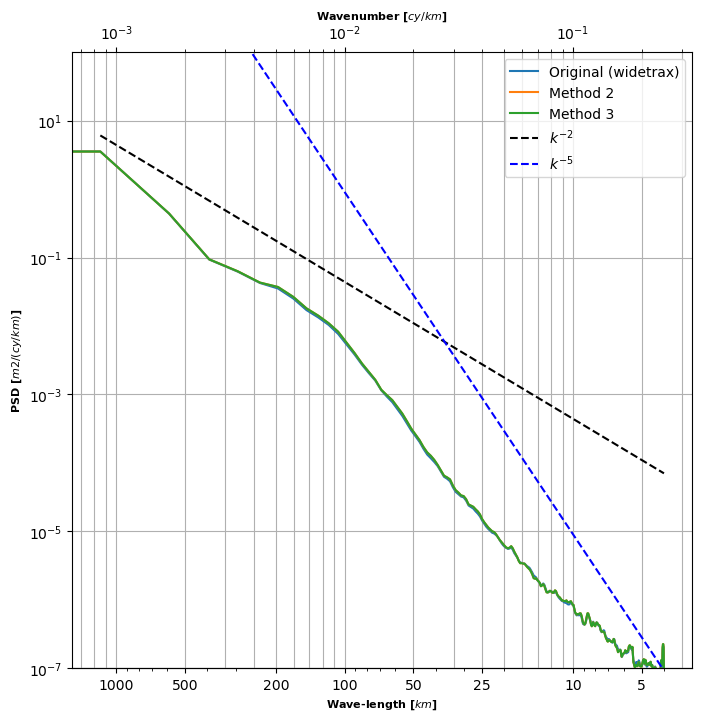

In [50]:
import matplotlib.pyplot as plt

fig, ax_ = plt.subplots(1, 1, figsize=(8, 8))
sp.plot_psd(ax_, freqs_mean_ori, [psd_mean_ori, psd_mean, psd_mean0], unit = "m2",psd_labels=["Original (widetrax)","Method 2","Method 3"],title=None,savefig=True,plot_transparent=False)
#sp.plot_psd(ax_, freqs_mean, psd_mean, unit = "m2",psd_labels="Method 2",title="PSD",savefig=True,plot_transparent=False)
#sp.plot_psd(ax_, freqs_mean0, psd_mean0, unit = "m2",psd_labels="Method 3",title=None,savefig=True,plot_transparent=False)


In [40]:
psd_mean_ori-psd_mean0

array([-1.42260769e-02,  1.44900279e-02, -2.83396268e-03, -7.06358250e-04,
       -8.03952317e-04, -6.19403181e-04, -1.85869087e-03, -1.43828693e-03,
       -1.04970373e-03, -8.26633723e-04, -6.10303452e-04, -5.91377351e-04,
       -3.57533178e-04, -1.99569084e-04, -1.17176044e-04, -8.58985125e-05,
       -4.38887272e-05, -2.31321043e-05, -4.47226221e-05, -5.47144975e-05,
       -4.65078371e-05, -3.99067596e-05, -2.95792568e-05, -1.97467373e-05,
       -1.38981723e-05, -1.25922215e-05, -1.00577903e-05, -1.00452405e-05,
       -1.00856333e-05, -7.44034096e-06, -3.73259950e-06, -3.05776152e-06,
       -2.36105440e-06, -2.76158959e-06, -3.57179528e-06, -2.61771245e-06,
       -2.23762045e-06, -1.91649909e-06, -1.21670423e-06, -1.40240954e-06,
       -1.41492904e-06, -8.84742431e-07, -1.10743906e-06, -1.33291249e-06,
       -1.40929821e-06, -1.37715258e-06, -1.16485928e-06, -7.40641905e-07,
       -6.85807737e-07, -7.32794689e-07, -5.49596615e-07, -4.90592276e-07,
       -4.72241816e-07, -

In [52]:
psd_mean-psd_mean0

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.69406589e-21,  

In [41]:
psd_mean_ori

array([2.02563393e-01, 3.54983880e+00, 4.37013949e-01, 9.33525949e-02,
       6.21262221e-02, 4.24589861e-02, 3.52648338e-02, 2.51697215e-02,
       1.70238347e-02, 1.33358261e-02, 1.03551448e-02, 7.65789120e-03,
       5.30714139e-03, 3.80430413e-03, 2.70653049e-03, 2.04265203e-03,
       1.59136336e-03, 1.14624874e-03, 9.26667526e-04, 7.69494657e-04,
       6.09117332e-04, 4.86666796e-04, 3.77931689e-04, 2.96508850e-04,
       2.44854793e-04, 2.02235140e-04, 1.60763292e-04, 1.32310200e-04,
       1.16884757e-04, 1.03092207e-04, 8.98106225e-05, 7.47019824e-05,
       6.25739160e-05, 5.86475937e-05, 5.37812987e-05, 4.38954698e-05,
       3.76505145e-05, 3.48824806e-05, 3.22226099e-05, 3.13160350e-05,
       2.80053878e-05, 2.38202204e-05, 2.25938360e-05, 2.14668737e-05,
       1.95614706e-05, 1.81100831e-05, 1.64381183e-05, 1.43400578e-05,
       1.28750839e-05, 1.16587958e-05, 1.08078008e-05, 1.01764815e-05,
       9.53189859e-06, 9.29910374e-06, 8.84375012e-06, 8.25903051e-06,
      

# CONCLUSION

* Method 2 and Method 3 are much faster. For box will take 2 min and 15 sec. For the global domain (i.e 280 boxes aprox) will be 10 hrs. In contrast the old method will be 186 hours.
* Although Method 2 and 3 have the same results, I think method 3 it will be more easy to implemented to the original code
* The results of the old method are not exactly the same as the other two method since it's including all the files of the last cycle (i.e it's including day from the next month that are in the last cycle)
* I applied some modification to Micael original code due to: (1) definition of longitude to be always in 0-360° (2) I used s3fs since it's more easy for me work. Micael used boto3. I don't know which will be better.
* I haven' try to paralellize the code. This can help to reduce time